In [1]:
import os
from pathlib import Path

PROJECT_ROOT = Path.cwd()
CACHE_DIR = PROJECT_ROOT / 'cache'
HF_CACHE_DIR = CACHE_DIR / 'huggingface'
HF_DATASETS_CACHE_DIR = HF_CACHE_DIR / 'datasets'
TRANSFORMERS_CACHE_DIR = CACHE_DIR / 'transformers'
KAGGLEHUB_CACHE_DIR = CACHE_DIR / 'kagglehub'
NLTK_DATA_DIR = CACHE_DIR / 'nltk_data'
TORCH_CACHE_DIR = CACHE_DIR / 'torch'
KERAS_CACHE_DIR = CACHE_DIR / 'keras'

for cache_path in [CACHE_DIR, HF_CACHE_DIR, HF_DATASETS_CACHE_DIR, TRANSFORMERS_CACHE_DIR, KAGGLEHUB_CACHE_DIR, NLTK_DATA_DIR, TORCH_CACHE_DIR, KERAS_CACHE_DIR]:
    cache_path.mkdir(parents=True, exist_ok=True)

os.environ['HF_HOME'] = str(HF_CACHE_DIR)
os.environ['HF_DATASETS_CACHE'] = str(HF_DATASETS_CACHE_DIR)
os.environ['HUGGINGFACE_HUB_CACHE'] = str(HF_CACHE_DIR / 'hub')
os.environ['TRANSFORMERS_CACHE'] = str(TRANSFORMERS_CACHE_DIR)
os.environ['KAGGLEHUB_CACHE'] = str(KAGGLEHUB_CACHE_DIR)
os.environ['NLTK_DATA'] = str(NLTK_DATA_DIR)
os.environ['TORCH_HOME'] = str(TORCH_CACHE_DIR)
os.environ['KERAS_HOME'] = str(KERAS_CACHE_DIR)
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'

import re
import json
import shutil
import joblib
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
from collections import Counter
import matplotlib.pyplot as plt
from datasets import load_dataset

print('Using project cache folder:', CACHE_DIR)


Using project cache folder: g:\College\semester 8\Foundation of Natural Language Processing\AI-vs-Human-Text-Detection\cache


## Human Text: Reddit 1M Comments Dataset

Human class: casual Reddit comments from `smagnan/1-million-reddit-comments-from-40-subreddits` (May 2019).  
Both classes are filtered to 8-120 words and balanced to 50,000 samples each.

In [2]:
sentence_raw_dir = Path('data/raw/sentence')
sentence_raw_dir.mkdir(parents=True, exist_ok=True)

reddit_1m_local = sentence_raw_dir / 'reddit_1m.csv'
REDDIT_KAGGLE = 'smagnan/1-million-reddit-comments-from-40-subreddits'
REDDIT_FILE   = 'kaggle_RC_2019-05.csv'

if reddit_1m_local.exists():
    print('Loading Reddit 1M from local file:', reddit_1m_local)
    reddit_raw = pd.read_csv(reddit_1m_local)
else:
    print('Downloading Reddit 1M dataset...')
    downloaded_path = Path(kagglehub.dataset_download(REDDIT_KAGGLE))
    src_file = next(downloaded_path.rglob(REDDIT_FILE), None)
    if src_file is None:
        raise FileNotFoundError(f'{REDDIT_FILE} not found in {downloaded_path}')
    shutil.copy(src_file, reddit_1m_local)
    reddit_raw = pd.read_csv(reddit_1m_local)
    print('Saved to:', reddit_1m_local)

Loading Reddit 1M from local file: data\raw\sentence\reddit_1m.csv


In [3]:
print('Shape:', reddit_raw.shape)
print('Columns:', reddit_raw.columns.tolist())
reddit_raw.head(3)

Shape: (1000000, 4)
Columns: ['subreddit', 'body', 'controversiality', 'score']


,subreddit,body,controversiality,score
0,gameofthrones,Your submission has been automatically removed...,0,1
1,aww,"Dont squeeze her with you massive hand, you me...",0,19
2,gaming,It's pretty well known and it was a paid produ...,0,3


In [4]:
for _candidate in ['body', 'comment', 'text', 'comment_text']:
    if _candidate in reddit_raw.columns:
        TEXT_COL = _candidate
        break
else:
    raise ValueError('Cannot identify text column. Available: '
                     + str(reddit_raw.columns.tolist()))

SUBREDDIT_COL = 'subreddit' if 'subreddit' in reddit_raw.columns else None
print(f'Text column   : {TEXT_COL}')
print(f'Subreddit col : {SUBREDDIT_COL}')

Text column   : body
Subreddit col : subreddit


In [5]:
keep_cols = [TEXT_COL] + ([SUBREDDIT_COL] if SUBREDDIT_COL else [])
df1 = reddit_raw[keep_cols].copy().rename(columns={TEXT_COL: 'text'})
del reddit_raw

df1 = df1[df1['text'].notna()]
df1 = df1[~df1['text'].str.strip().isin(
    ['[deleted]', '[removed]', 'deleted', 'removed', '']
)]

_url_only = (df1['text'].str.strip().str.startswith('http') &
             ~df1['text'].str.contains(' ', na=False))
df1 = df1[~_url_only]

df1['word_count'] = df1['text'].str.split().str.len()
df1 = df1[(df1['word_count'] >= 8) & (df1['word_count'] <= 120)]
df1 = df1.drop_duplicates(subset='text').reset_index(drop=True)
df1['source'] = 0

print(f'Filtered Reddit human texts: {len(df1):,}')
df1.head(3)

Filtered Reddit human texts: 722,826


,text,subreddit,word_count,source
0,Your submission has been automatically removed...,gameofthrones,70,0
1,"Dont squeeze her with you massive hand, you me...",aww,10,0
2,It's pretty well known and it was a paid produ...,gaming,65,0


In [6]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 722826 entries, 0 to 722825
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   text        722826 non-null  object
 1   subreddit   722826 non-null  object
 2   word_count  722826 non-null  int64 
 3   source      722826 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 22.1+ MB


In [7]:
df1.shape

(722826, 4)

In [8]:
hf_local_path = Path('data/raw/sentence/ai_text_detection_pile.csv')
hf_local_path.parent.mkdir(parents=True, exist_ok=True)

if hf_local_path.exists():
    print('Loading dataset from local file:', hf_local_path)
    df2 = pd.read_csv(hf_local_path)
else:
    print('Local dataset not found. Downloading...')
    hf_dataset = load_dataset(
        'artem9k/ai-text-detection-pile',
        split='train',
        cache_dir=str(HF_DATASETS_CACHE_DIR)
    )
    df2 = hf_dataset.to_pandas()
    df2.to_csv(hf_local_path, index=False)
    print('Dataset saved locally:', hf_local_path)


Loading dataset from local file: data\raw\sentence\ai_text_detection_pile.csv


In [9]:
df2.head()

,source,id,text
0,human,0,12 Years a Slave: An Analysis of the Film Essa...
1,human,1,20+ Social Media Post Ideas to Radically Simpl...
2,human,2,2022 Russian Invasion of Ukraine in Global Med...
3,human,3,533 U.S. 27 (2001) Kyllo v. United States: The...
4,human,4,A Charles Schwab Corporation Case Essay\n\nCha...


In [10]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1392522 entries, 0 to 1392521
Data columns (total 3 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   source  1392522 non-null  object
 1   id      1392522 non-null  int64 
 2   text    1392362 non-null  object
dtypes: int64(1), object(2)
memory usage: 31.9+ MB


In [11]:
df2.shape

(1392522, 3)

In [12]:
df2.duplicated().sum()

0

In [13]:
def filter_ai_generated(df):
    if 'source' not in df.columns:
        raise ValueError("The DataFrame must have a 'source' column.")
    
    df2 = df[df['source'] == 'ai'].copy()
    return df2

In [14]:
df2 = filter_ai_generated(df2)
df2.head()


,source,id,text
1028146,ai,1048108,\nSure! The process for setting up a hydroponi...
1028147,ai,1048109,The best type of wine to pair with steak depe...
1028148,ai,1048110,\n\nAnswer: To determine if an investment is a...
1028149,ai,1048111,\n\nSome financial advice is to always pay you...
1028150,ai,1048112,\nThe type of safety devices you should instal...


In [15]:
df2.shape

(364376, 3)

In [16]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 364376 entries, 1028146 to 1392521
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   source  364376 non-null  object
 1   id      364376 non-null  int64 
 2   text    364216 non-null  object
dtypes: int64(1), object(2)
memory usage: 11.1+ MB


In [17]:
df2 = df2.drop(columns=['id'])

df2['word_count'] = df2['text'].str.split().str.len()
df2 = df2[(df2['word_count'] >= 8) & (df2['word_count'] <= 120)]
df2 = df2.reset_index(drop=True)

print(f'AI texts after length filter (8-120 words): {len(df2):,}')

AI texts after length filter (8-120 words): 95,980


In [18]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95980 entries, 0 to 95979
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   source      95980 non-null  object 
 1   text        95980 non-null  object 
 2   word_count  95980 non-null  float64
dtypes: float64(1), object(2)
memory usage: 2.2+ MB


In [19]:
df2['source'] = df2['source'].apply(lambda x: 1 if x == 'ai' else 0)

In [20]:
df2.head()

,source,text,word_count
0,1,The best type of wine to pair with steak depe...,104.0
1,1,\n\nAnswer: To determine if an investment is a...,66.0
2,1,\n\nSome financial advice is to always pay you...,77.0
3,1,\nThe type of safety devices you should instal...,57.0
4,1,"To interpret the results of your blood test, ...",54.0


In [21]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95980 entries, 0 to 95979
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   source      95980 non-null  int64  
 1   text        95980 non-null  object 
 2   word_count  95980 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 2.2+ MB


In [22]:
df2.duplicated().sum()

582

In [23]:
df2.drop_duplicates(inplace=True)

In [24]:
df2.duplicated().sum()

0

In [25]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 722826 entries, 0 to 722825
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   text        722826 non-null  object
 1   subreddit   722826 non-null  object
 2   word_count  722826 non-null  int64 
 3   source      722826 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 22.1+ MB


In [26]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95398 entries, 0 to 95979
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   source      95398 non-null  int64  
 1   text        95398 non-null  object 
 2   word_count  95398 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 2.9+ MB


In [27]:
N_PER_CLASS = 95_000
n = min(len(df1), len(df2), N_PER_CLASS)
print(f'Samples per class: {n:,}')

human_sampled = df1.sample(n=n, random_state=42)
ai_sampled    = df2[['text', 'source']].sample(n=n, random_state=42)

sampled_subreddits = (
    human_sampled[SUBREDDIT_COL].reset_index(drop=True)
    if SUBREDDIT_COL and SUBREDDIT_COL in human_sampled.columns else None
)
human_sampled = human_sampled[['text', 'source']].reset_index(drop=True)

df = pd.concat([human_sampled, ai_sampled], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Final balanced dataset: {len(df):,} rows')
print(df['source'].value_counts())

Samples per class: 95,000
Final balanced dataset: 190,000 rows
source
1    95000
0    95000
Name: count, dtype: int64


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190000 entries, 0 to 189999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    190000 non-null  object
 1   source  190000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 2.9+ MB


In [29]:
df['source'].unique()

array([1, 0], dtype=int64)

In [30]:
df.duplicated().sum()

0

## Dataset Verification

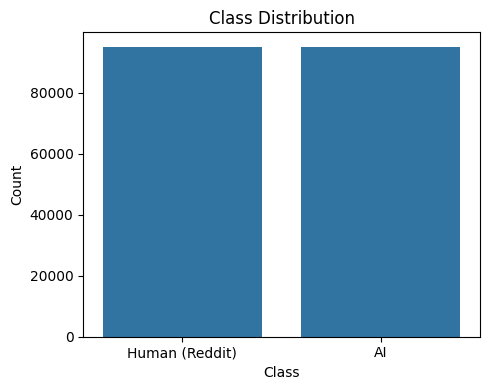

In [31]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x='source', ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Human (Reddit)', 'AI'])
ax.set_title('Class Distribution')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

In [32]:
df['_wc'] = df['text'].str.split().str.len()
df['_cl'] = df['text'].str.len()

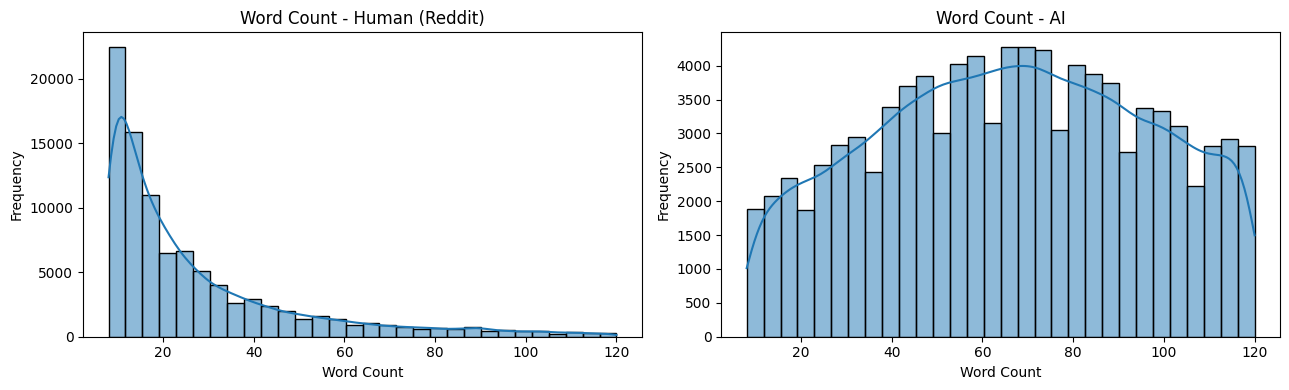

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for src, label, ax in zip([0, 1], ['Human (Reddit)', 'AI'], axes):
    sns.histplot(df[df['source'] == src]['_wc'], bins=30, kde=True, ax=ax)
    ax.set_title(f'Word Count - {label}')
    ax.set_xlabel('Word Count')
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

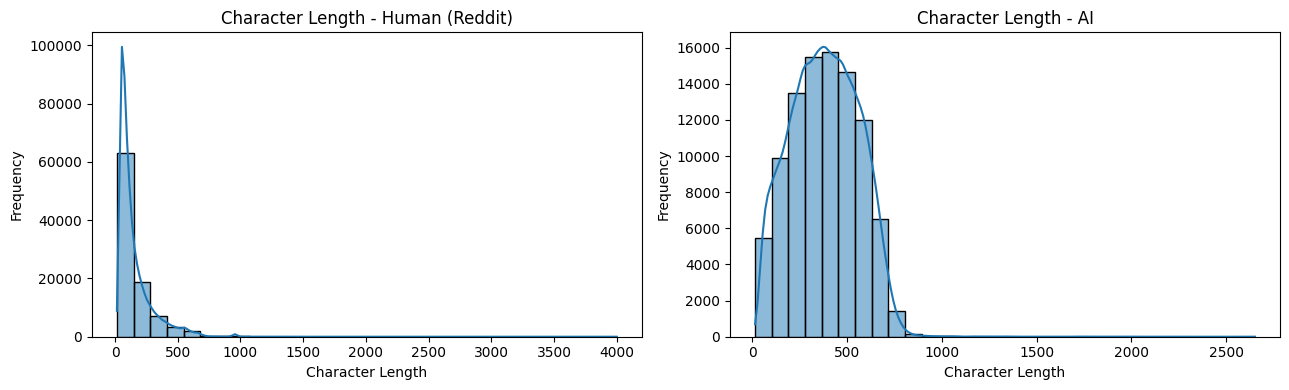

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for src, label, ax in zip([0, 1], ['Human (Reddit)', 'AI'], axes):
    sns.histplot(df[df['source'] == src]['_cl'], bins=30, kde=True, ax=ax)
    ax.set_title(f'Character Length - {label}')
    ax.set_xlabel('Character Length')
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

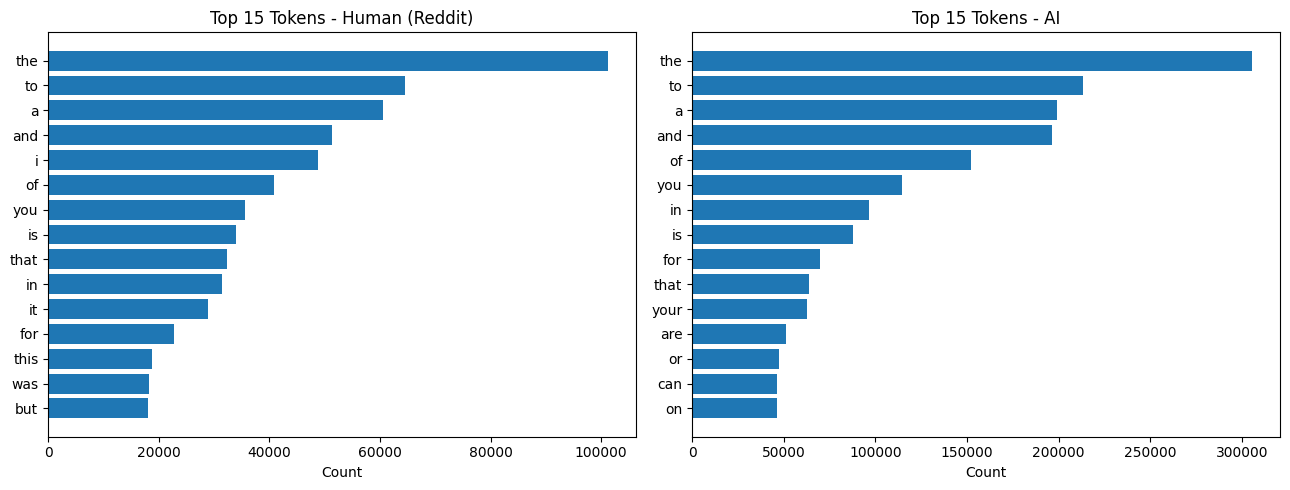

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for src, label, ax in zip([0, 1], ['Human (Reddit)', 'AI'], axes):
    tokens = ' '.join(df[df['source'] == src]['text']).lower().split()
    top15 = Counter(tokens).most_common(15)
    words_t, counts_t = zip(*top15)
    ax.barh(list(words_t)[::-1], list(counts_t)[::-1])
    ax.set_title(f'Top 15 Tokens - {label}')
    ax.set_xlabel('Count')
plt.tight_layout()
plt.show()

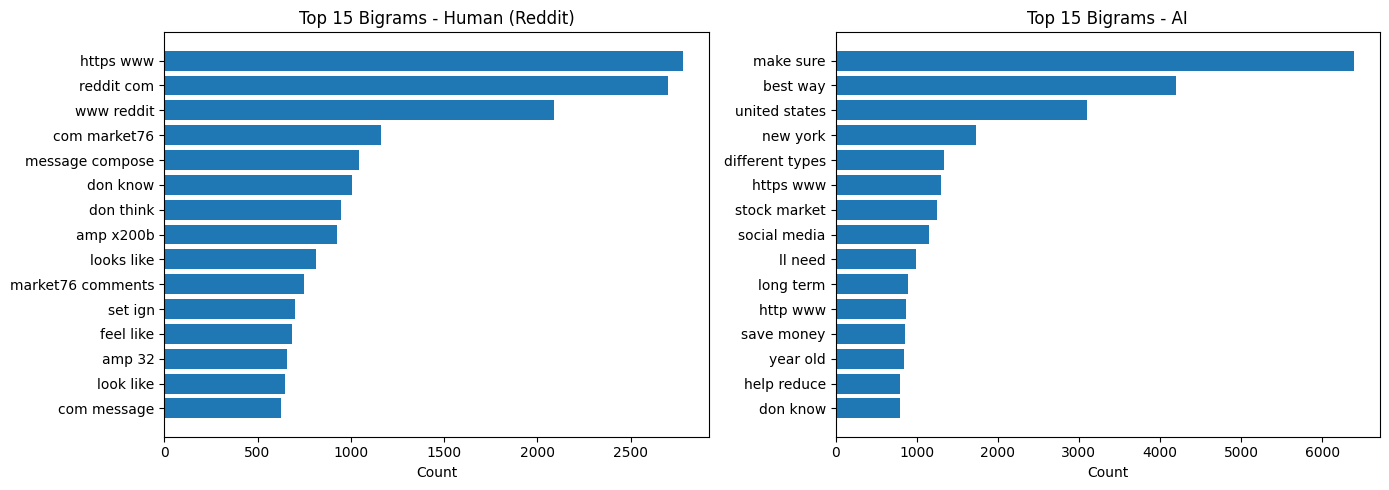

In [37]:
from sklearn.feature_extraction.text import CountVectorizer

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for src, label, ax in zip([0, 1], ['Human (Reddit)', 'AI'], axes):
    texts_src = df[df['source'] == src]['text'].astype(str).tolist()
    vec = CountVectorizer(ngram_range=(2, 2), max_features=15, stop_words='english')
    X_bg = vec.fit_transform(texts_src)
    bg_counts = X_bg.sum(axis=0).A1
    bigrams = vec.get_feature_names_out()
    top_idx = bg_counts.argsort()[::-1][:15]
    ax.barh([bigrams[i] for i in top_idx][::-1],
            [bg_counts[i] for i in top_idx][::-1])
    ax.set_title(f'Top 15 Bigrams - {label}')
    ax.set_xlabel('Count')
plt.tight_layout()
plt.show()

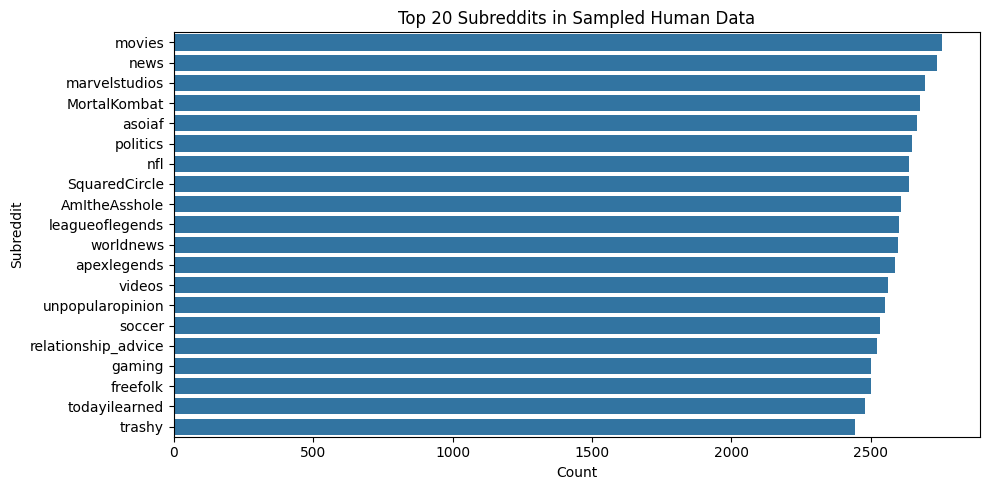

In [38]:
if sampled_subreddits is not None:
    top_subs = sampled_subreddits.value_counts().head(20)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=top_subs.values, y=top_subs.index)
    plt.title('Top 20 Subreddits in Sampled Human Data')
    plt.xlabel('Count')
    plt.ylabel('Subreddit')
    plt.tight_layout()
    plt.show()
else:
    print('Subreddit column not available in this dataset.')

Preproccessing

<Axes: xlabel='source', ylabel='count'>

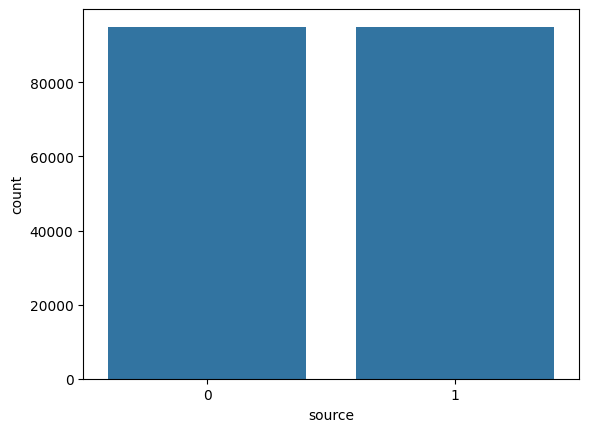

In [39]:
sns.countplot(data=df,x='source')

In [40]:
df['text'][0]

"T-Mobile, Sprint or AT&T\n\nWe'll check with the wireless carrier. If it is in your area, we'll help you find a network that matches your service.\n\nIf the carriers do not offer it, we can buy your service.\n\nPlease enter one of the service's four network numbers:"

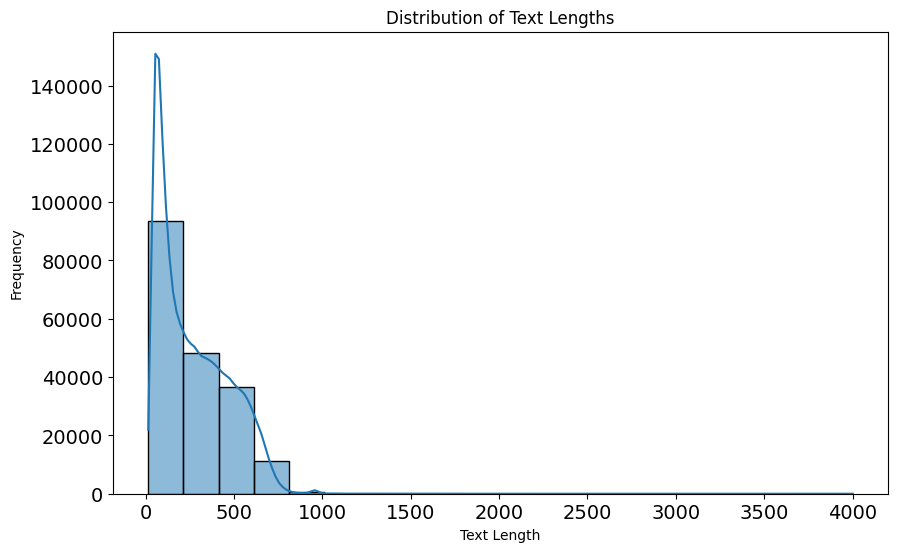

In [41]:
df['text_length'] = df['text'].apply(len)
plt.figure(figsize=(10, 6))
sns.histplot(df['text_length'], bins=20, kde=True)
plt.title("Distribution of Text Lengths")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

In [42]:
df['text_length'].describe()

count    190000.000000
mean        269.695342
std         198.375316
min          15.000000
25%          93.000000
50%         220.000000
75%         418.000000
max        4001.000000
Name: text_length, dtype: float64

In [43]:
df = df.drop(columns=['text_length'])

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190000 entries, 0 to 189999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    190000 non-null  object
 1   source  190000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 2.9+ MB


In [45]:
df['text'][0]

"T-Mobile, Sprint or AT&T\n\nWe'll check with the wireless carrier. If it is in your area, we'll help you find a network that matches your service.\n\nIf the carriers do not offer it, we can buy your service.\n\nPlease enter one of the service's four network numbers:"

In [46]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'[\U00010000-\U0010ffff]', ' ', text)
    text = re.sub(r"[^a-z0-9\s\.,!\?;:'-]", ' ', text)
    text = re.sub(r'(.)\1{4,}', r'\1\1', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

In [47]:
df = df.drop_duplicates(subset='text').dropna(subset=['text'])
df['cleaned_text'] = df['text'].apply(clean_text)
df['word_count'] = df['cleaned_text'].str.split().str.len()
df = df[(df['cleaned_text'] != '') & (df['word_count'] >= 6)]
df = df.drop_duplicates(subset='cleaned_text').reset_index(drop=True)

In [48]:
df[['text', 'cleaned_text', 'word_count']].head()

,text,cleaned_text,word_count
0,"T-Mobile, Sprint or AT&T\n\nWe'll check with t...","t-mobile, sprint or at t we'll check with the ...",48
1,"\n\nBased on a variety of factors, some of the...","based on a variety of factors, some of the hig...",36
2,Depending on if you count UAVs it’s the Army iirc,depending on if you count uavs it s the army iirc,11
3,Possible Stock Ticker Symbols for PSEC:PSEC: T...,possible stock ticker symbols for psec:psec: t...,105
4,\n\n\n The Kyoto Protocol was agreed upon betw...,the kyoto protocol was agreed upon between nat...,76


In [49]:
df['cleaned_text'][0]

"t-mobile, sprint or at t we'll check with the wireless carrier. if it is in your area, we'll help you find a network that matches your service. if the carriers do not offer it, we can buy your service. please enter one of the service's four network numbers:"

In [50]:
df.head()

,text,source,cleaned_text,word_count
0,"T-Mobile, Sprint or AT&T\n\nWe'll check with t...",1,"t-mobile, sprint or at t we'll check with the ...",48
1,"\n\nBased on a variety of factors, some of the...",1,"based on a variety of factors, some of the hig...",36
2,Depending on if you count UAVs it’s the Army iirc,0,depending on if you count uavs it s the army iirc,11
3,Possible Stock Ticker Symbols for PSEC:PSEC: T...,1,possible stock ticker symbols for psec:psec: t...,105
4,\n\n\n The Kyoto Protocol was agreed upon betw...,1,the kyoto protocol was agreed upon between nat...,76


In [51]:
top_words = Counter(" ".join(df[df['source'] == 0]['cleaned_text']).split()).most_common(10)
top_words

[('the', 101664),
 ('to', 64398),
 ('a', 60543),
 ('i', 54129),
 ('and', 51777),
 ('of', 40743),
 ('you', 37721),
 ('that', 33980),
 ('is', 33949),
 ('it', 32925)]

In [52]:
top_words = Counter(" ".join(df[df['source'] == 1]['cleaned_text']).split()).most_common(10)
top_words

[('the', 309214),
 ('to', 213522),
 ('a', 201224),
 ('and', 197438),
 ('of', 152142),
 ('you', 121862),
 ('in', 96882),
 ('is', 88042),
 ('for', 70279),
 ('that', 66068)]

In [53]:
import nltk
from nltk.tokenize import word_tokenize

nltk.data.path.insert(0, str(NLTK_DATA_DIR))
nltk.download('punkt', download_dir=str(NLTK_DATA_DIR))
nltk.download('punkt_tab', download_dir=str(NLTK_DATA_DIR), quiet=True)

df['tokenized_text'] = df['cleaned_text'].apply(word_tokenize)


[nltk_data] Downloading package punkt to g:\College\semester
[nltk_data]     8\Foundation of Natural Language Processing\AI-vs-
[nltk_data]     Human-Text-Detection\cache\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [54]:
from nltk.corpus import stopwords

nltk.download('stopwords', download_dir=str(NLTK_DATA_DIR))

viz_stop_words = set(stopwords.words('english'))


[nltk_data] Downloading package stopwords to g:\College\semester
[nltk_data]     8\Foundation of Natural Language Processing\AI-vs-
[nltk_data]     Human-Text-Detection\cache\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [55]:
df['viz_tokens_no_stopwords'] = df['tokenized_text'].apply(
    lambda tokens: [word for word in tokens if word.lower() not in viz_stop_words]
)

In [56]:
all_tokens = [token for tokens_list in df[df['source'] == 0]['viz_tokens_no_stopwords'] for token in tokens_list]
Counter(all_tokens).most_common(10)

[('.', 139468),
 (',', 78407),
 ("'s", 21305),
 ('?', 20929),
 ("n't", 19398),
 ('like', 14090),
 ('!', 10217),
 ('would', 9570),
 (':', 9404),
 ('people', 9357)]

In [57]:
all_tokens = [token for tokens_list in df[df['source'] == 1]['viz_tokens_no_stopwords'] for token in tokens_list]
Counter(all_tokens).most_common(10)

[(',', 360068),
 ('.', 302996),
 ('also', 26736),
 ("'s", 26258),
 ('?', 25486),
 (':', 23312),
 ('make', 18087),
 ('help', 16943),
 ('want', 16760),
 ('use', 15988)]

In [58]:
df['tokenized_text'][0]

['t-mobile',
 ',',
 'sprint',
 'or',
 'at',
 't',
 'we',
 "'ll",
 'check',
 'with',
 'the',
 'wireless',
 'carrier',
 '.',
 'if',
 'it',
 'is',
 'in',
 'your',
 'area',
 ',',
 'we',
 "'ll",
 'help',
 'you',
 'find',
 'a',
 'network',
 'that',
 'matches',
 'your',
 'service',
 '.',
 'if',
 'the',
 'carriers',
 'do',
 'not',
 'offer',
 'it',
 ',',
 'we',
 'can',
 'buy',
 'your',
 'service',
 '.',
 'please',
 'enter',
 'one',
 'of',
 'the',
 'service',
 "'s",
 'four',
 'network',
 'numbers',
 ':']

In [59]:
from nltk.stem import WordNetLemmatizer
import nltk

nltk.data.path.insert(0, str(NLTK_DATA_DIR))
nltk.download('wordnet', download_dir=str(NLTK_DATA_DIR))
nltk.download('omw-1.4', download_dir=str(NLTK_DATA_DIR), quiet=True)

lemmatizer = WordNetLemmatizer()

def lemmatize_text(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df['lemmatized_text'] = df['tokenized_text'].apply(lemmatize_text)


[nltk_data] Downloading package wordnet to g:\College\semester
[nltk_data]     8\Foundation of Natural Language Processing\AI-vs-
[nltk_data]     Human-Text-Detection\cache\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [60]:
all_tokens = [token for tokens_list in df[df['source'] == 0]['lemmatized_text'] for token in tokens_list]
Counter(all_tokens).most_common(10)

[('.', 139468),
 ('the', 101816),
 (',', 78407),
 ('a', 72546),
 ('to', 65239),
 ('i', 63129),
 ('and', 51993),
 ('it', 49640),
 ('you', 44720),
 ('of', 40951)]

In [61]:
all_tokens = [token for tokens_list in df[df['source'] == 1]['lemmatized_text'] for token in tokens_list]
Counter(all_tokens).most_common(10)

[(',', 360068),
 ('the', 309284),
 ('.', 302996),
 ('a', 243375),
 ('to', 214420),
 ('and', 197763),
 ('of', 152447),
 ('you', 131497),
 ('in', 98186),
 ('is', 90114)]

In [62]:
import gc

Path('data').mkdir(exist_ok=True)
MODEL_DATA_PATH = Path('data/sentence_model.pkl')
modeling_df = df[['cleaned_text', 'source']].copy()
modeling_df['source'] = modeling_df['source'].astype('int8')
modeling_df.to_pickle(MODEL_DATA_PATH)

heavy_columns = ['text', 'word_count', 'tokenized_text', 'viz_tokens_no_stopwords', 'lemmatized_text']
df = modeling_df
for name in ['modeling_df', 'all_tokens']:
    if name in globals():
        del globals()[name]
gc.collect()

print(f'Saved compact modeling data to {MODEL_DATA_PATH}')
print('Current df columns:', df.columns.tolist())
print('Rows:', len(df))


Saved compact modeling data to data\sentence_model.pkl
Current df columns: ['cleaned_text', 'source']
Rows: 187806


The following section is designated for machine learning models.

In [63]:
import gc

MODEL_DATA_PATH = Path('data/sentence_model.pkl')
required_columns = {'cleaned_text', 'source'}

if 'df' in globals() and required_columns.issubset(df.columns):
    df = df[['cleaned_text', 'source']].copy()
    df['source'] = df['source'].astype('int8')
    print('Using existing in-memory compact df; no file was read.')
elif MODEL_DATA_PATH.exists():
    df = pd.read_pickle(MODEL_DATA_PATH)
    print('Loaded compact modeling data from:', MODEL_DATA_PATH)
else:
    raise FileNotFoundError(
        f'{MODEL_DATA_PATH} does not exist. Run the preprocessing/save cell first. '
        'The old data/sentence.pkl can be too large to load safely.'
    )

gc.collect()
print(df.info(memory_usage='deep'))


Using existing in-memory compact df; no file was read.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187806 entries, 0 to 187805
Data columns (total 2 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   cleaned_text  187806 non-null  object
 1   source        187806 non-null  int8  
dtypes: int8(1), object(1)
memory usage: 57.5 MB
None


In [64]:
print(type(df['cleaned_text'][0]))
print(df['cleaned_text'][0])

<class 'str'>
t-mobile, sprint or at t we'll check with the wireless carrier. if it is in your area, we'll help you find a network that matches your service. if the carriers do not offer it, we can buy your service. please enter one of the service's four network numbers:


In [65]:
X = df['cleaned_text']
y = df['source']

In [66]:
X.head()

0    t-mobile, sprint or at t we'll check with the ...
1    based on a variety of factors, some of the hig...
2    depending on if you count uavs it s the army iirc
3    possible stock ticker symbols for psec:psec: t...
4    the kyoto protocol was agreed upon between nat...
Name: cleaned_text, dtype: object

In [67]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [68]:
print(len(X_train))
print(len(y_train))

131464
131464


In [69]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from xgboost.core import XGBoostError
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report


In [70]:
def make_tfidf_pipeline(classifier, **tfidf_overrides):
    tfidf_params = {
        'ngram_range': (1, 2),
        'min_df': 2,
        'max_df': 0.95,
        'sublinear_tf': True,
        'dtype': np.float32
    }
    tfidf_params.update(tfidf_overrides)
    return Pipeline([
        ('tfidf', TfidfVectorizer(**tfidf_params)),
        ('classifier', classifier)
    ])

pipelines = {
    'Naive Bayes': make_tfidf_pipeline(MultinomialNB()),
    'Logistic Regression': make_tfidf_pipeline(LogisticRegression(max_iter=1000)),
    'Passive Aggressive': make_tfidf_pipeline(PassiveAggressiveClassifier(max_iter=1000, random_state=42)),
    'Random Forest': make_tfidf_pipeline(
        RandomForestClassifier(
            n_estimators=50,
            max_depth=40,
            min_samples_leaf=2,
            n_jobs=-1,
            random_state=42
        ),
        ngram_range=(1, 1),
        min_df=5,
        max_features=20000
    ),
    'XGBoost': make_tfidf_pipeline(
        XGBClassifier(
            booster='gblinear',
            objective='binary:logistic',
            eval_metric='logloss',
            n_estimators=50,
            learning_rate=0.1,
            n_jobs=1,
            random_state=42
        ),
        ngram_range=(1, 1),
        min_df=10,
        max_features=10000
    )
}

ml_model_files = {
    'Naive Bayes': 'sentence_naive_bayes.pkl',
    'Logistic Regression': 'sentence_logistic_regression.pkl',
    'Passive Aggressive': 'sentence_passive_aggressive.pkl',
    'Random Forest': 'sentence_random_forest.pkl',
    'XGBoost': 'sentence_xgboost.pkl'
}


In [71]:
ml_metrics = []
trained_ml_pipelines = {}

for model_name, pipeline in pipelines.items():
    try:
        pipeline.fit(X_train, y_train)
    except (MemoryError, XGBoostError) as exc:
        print(f'Skipping {model_name}: not enough memory to train this model on the current dataset.')
        print(exc)
        continue

    y_pred = pipeline.predict(X_test)
    trained_ml_pipelines[model_name] = pipeline

    ml_metrics.append({
        'model': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0)
    })

    print(model_name)
    print(classification_report(y_test, y_pred))


Naive Bayes
              precision    recall  f1-score   support

           0       0.93      0.92      0.93     27995
           1       0.92      0.93      0.93     28347

    accuracy                           0.93     56342
   macro avg       0.93      0.93      0.93     56342
weighted avg       0.93      0.93      0.93     56342

Logistic Regression
              precision    recall  f1-score   support

           0       0.95      0.96      0.95     27995
           1       0.96      0.95      0.95     28347

    accuracy                           0.95     56342
   macro avg       0.95      0.95      0.95     56342
weighted avg       0.95      0.95      0.95     56342

Passive Aggressive
              precision    recall  f1-score   support

           0       0.96      0.96      0.96     27995
           1       0.96      0.96      0.96     28347

    accuracy                           0.96     56342
   macro avg       0.96      0.96      0.96     56342
weighted avg       0.96

In [72]:
ml_metrics_df = pd.DataFrame(ml_metrics).sort_values('f1', ascending=False)
ml_metrics_df

,model,accuracy,precision,recall,f1
2,Passive Aggressive,0.963047,0.963015,0.963559,0.963287
1,Logistic Regression,0.952540,0.958266,0.946908,0.952553
4,XGBoost,0.932076,0.923372,0.943274,0.933217
0,Naive Bayes,0.927319,0.923897,0.932339,0.928099
3,Random Forest,0.892620,0.920905,0.860479,0.889667


In [73]:
model_dir = Path('models/sentence/ml')
model_dir.mkdir(parents=True, exist_ok=True)

for model_name, pipeline in trained_ml_pipelines.items():
    joblib.dump(pipeline, model_dir / ml_model_files[model_name])

In [74]:
metrics_dir = Path('models/sentence')
metrics_dir.mkdir(parents=True, exist_ok=True)

ml_metrics_df.to_csv(metrics_dir / 'sentence_ml_metrics.csv', index=False)
with open(metrics_dir / 'sentence_ml_metrics.json', 'w', encoding='utf-8') as file:
    json.dump(ml_metrics, file, indent=2)

In [75]:
import gc

legacy_model_dir = Path('models')
legacy_model_dir.mkdir(exist_ok=True)

pa_pipeline = trained_ml_pipelines.get('Passive Aggressive')
if pa_pipeline is not None:
    legacy_path = legacy_model_dir / 'sentences_passive_aggressive_pipeline.pkl'
    joblib.dump(pa_pipeline, legacy_path)
    print('Passive Aggressive legacy pipeline saved to:', legacy_path)
else:
    print('Passive Aggressive was not trained, so the legacy pipeline was not saved.')

for name in [
    'nb_pipeline', 'logreg_pipeline', 'pa_pipeline', 'rf_pipeline', 'xgb_pipeline',
    'trained_ml_pipelines', 'pipelines', 'pipeline', 'X', 'y', 'X_train', 'X_test', 'y_train', 'y_test',
    'ml_metrics', 'ml_metrics_df', 'y_pred'
]:
    if name in globals():
        del globals()[name]

gc.collect()
print('Released ML training objects from memory.')


Passive Aggressive legacy pipeline saved to: models\sentences_passive_aggressive_pipeline.pkl
Released ML training objects from memory.


The following section is designated for deep learning models.

In [76]:
print(type(df['cleaned_text'][0]))
print(df['cleaned_text'][0])

<class 'str'>
t-mobile, sprint or at t we'll check with the wireless carrier. if it is in your area, we'll help you find a network that matches your service. if the carriers do not offer it, we can buy your service. please enter one of the service's four network numbers:


In [77]:
from sklearn.model_selection import train_test_split
import gc
import torch
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

texts = df['cleaned_text'].astype(str).tolist()
y = df['source'].astype('int8').values
max_vocab_size = 10000
max_len = int(np.percentile([len(text.split()) for text in texts], 95))
max_len = max(20, min(max_len, 120))

tokenizer = Tokenizer(num_words=max_vocab_size, oov_token='<OOV>', filters='', lower=False)
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)
padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')
del sequences
gc.collect()

X_train, X_test, y_train, y_test = train_test_split(
    padded_sequences, y, test_size=0.3, random_state=42, stratify=y
)
del padded_sequences, y, texts
gc.collect()

X_train_tensor = torch.tensor(X_train, dtype=torch.long)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)
del X_train, X_test, y_train, y_test
gc.collect()

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

vocab_size = max_vocab_size + 1
label_mapping = {'human': 0, 'ai': 1}
print(f"Vocabulary size for embedding: {vocab_size}")
print(f"Sequence length: {max_len}")


Vocabulary size for embedding: 10001
Sequence length: 109


In [78]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import RobertaModel, ElectraModel

vocab_size = 29500  
embed_dim = 100    
hidden_dim=64                        

class DNNModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes):
        super(DNNModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.global_avg_pool = lambda x: torch.mean(x, dim=1)  
        self.fc1 = nn.Linear(embed_dim, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 64)
        self.output = nn.Linear(64, num_classes)
        
    def forward(self, x):
        x = self.embedding(x)             
        x = self.global_avg_pool(x)       
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        x = self.output(x)
        return x

class BiLSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
        super(BiLSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)

        self.output = nn.Linear(2 * hidden_dim, output_dim) 

    def forward(self, x):
        x = self.embedding(x)
        _, (h_n, _) = self.lstm(x)
        x = torch.cat((h_n[-2, :, :], h_n[-1, :, :]), dim=1)
        x = self.output(x) 
        return x


class CNNModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes):
        super(CNNModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.conv1d = nn.Conv1d(in_channels=embed_dim, out_channels=128, kernel_size=5)
        self.global_max_pool = nn.AdaptiveMaxPool1d(1) 
        self.fc1 = nn.Linear(128, 64)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.embedding(x)  
        x = x.permute(0, 2, 1) 
        x = torch.relu(self.conv1d(x))
        x = self.global_max_pool(x).squeeze(-1)  
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


class GRUModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, gru_hidden_dim, num_classes):
        super(GRUModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.gru = nn.GRU(embed_dim, gru_hidden_dim, batch_first=True) 
        self.fc1 = nn.Linear(gru_hidden_dim, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 64)
        self.output = nn.Linear(64, num_classes)
        
    def forward(self, x):
        x = self.embedding(x)                 
        _, hn = self.gru(x)                   
        x = hn[-1]                            
        x = torch.relu(self.fc1(x))           
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))           
        x = self.output(x)                    
        return x
    

g:\programs\Python\Python310\lib\site-packages\transformers\utils\hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [79]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, auc
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelBinarizer

def evaluate_model(model, data_loader, device):
    model.eval()
    all_labels_list, all_preds_list, all_probs_raw_list = [], [], []

    num_classes = 0
    if hasattr(model, 'output'):
        num_classes = model.output.out_features
    elif hasattr(model, 'fc2'):
        num_classes = model.fc2.out_features
    elif hasattr(model, 'fc') and isinstance(model.fc, nn.Linear):
        num_classes = model.fc.out_features
    else:
        raise AttributeError("Could not determine num_classes from model's output layer (expected 'output', 'fc2', or 'fc').")

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            if labels.dim() == 2 and labels.size(1) == 1:
                labels = labels.squeeze(1)

            outputs = model(inputs)

            if num_classes > 1:
                probs = F.softmax(outputs, dim=1)
                all_probs_raw_list.extend(probs.cpu().numpy())
                
                _, preds = torch.max(outputs, 1)
                all_preds_list.extend(preds.cpu().numpy())
                all_labels_list.extend(labels.cpu().numpy())
            else:
                outputs_sigmoid = torch.sigmoid(outputs)
                probs = outputs_sigmoid.cpu().numpy()
                all_probs_raw_list.extend(probs.flatten()) 
                
                preds = (outputs_sigmoid >= 0.5).float().cpu().numpy()
                all_preds_list.extend(preds.flatten())
                all_labels_list.extend(labels.cpu().numpy().flatten())

    all_labels = np.array(all_labels_list).flatten().astype(int) 
    all_preds = np.array(all_preds_list).flatten().astype(int)

    if num_classes == 2:
        all_probs_for_auc = np.array(all_probs_raw_list) 
        if all_probs_for_auc.ndim == 2: 
            all_probs_for_auc = all_probs_for_auc[:, 1]
        elif all_probs_for_auc.ndim == 1 and np.unique(all_labels).size == 2: 
            pass 
        else:
            print("Warning: Unexpected shape for all_probs_raw_list in binary evaluation. Reshaping to 1D.")
            all_probs_for_auc = all_probs_for_auc.flatten()
            
    elif num_classes > 2:
        all_probs_for_auc = np.array(all_probs_raw_list) 
        if all_probs_for_auc.ndim == 1 and num_classes > 1:
            print(f"Warning: all_probs_raw_list is 1D for multi-class {num_classes}. This is likely incorrect for AUC.")
            
    else: 
        all_probs_for_auc = np.array(all_probs_raw_list).flatten() 

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    
    roc_auc = float('nan')
    if num_classes == 2:
        try:
            roc_auc = roc_auc_score(all_labels, all_probs_for_auc)
        except ValueError:
            roc_auc = 0.0
    elif num_classes > 2:
        if all_probs_for_auc.shape == (len(all_labels), num_classes):
            try:
                roc_auc = roc_auc_score(all_labels, all_probs_for_auc, multi_class='ovr', average='weighted')
            except ValueError:
                roc_auc = 0.0
        else:
            print(f"Warning: all_probs_for_auc shape {all_probs_for_auc.shape} mismatch with expected ({len(all_labels)}, {num_classes}) for multi-class AUC.")

    cm = confusion_matrix(all_labels, all_preds)

    print(f"Evaluation - Accuracy:  {accuracy:.4f}")
    print(f"Evaluation - Precision: {precision:.4f}")
    print(f"Evaluation - Recall:    {recall:.4f}")
    print(f"Evaluation - F1 Score:  {f1:.4f}")
    if not np.isnan(roc_auc):
        print(f"Evaluation - AUC-ROC:   {roc_auc:.4f}")
    else:
        print("Evaluation - AUC-ROC:   Not applicable or calculation failed for AUC-ROC.")

    return all_labels, all_probs_for_auc, cm


def plot_confusion_matrix(cm, labels=None):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()


def plot_roc_curve(y_true, y_probs, num_classes, class_labels=None):
    y_true = np.array(y_true).flatten().astype(int)

    if num_classes == 2:
        if y_probs.ndim > 1 and y_probs.shape[1] == 2:
            y_probs = y_probs[:, 1]
        elif y_probs.ndim > 1 and y_probs.shape[1] == 1:
            y_probs = y_probs.flatten() 

        fpr, tpr, _ = roc_curve(y_true, y_probs)
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve")
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.show()
    elif num_classes > 2:
        print("\nPlotting One-vs-Rest ROC Curves for multi-class.")
        plt.figure(figsize=(8, 7))
        
        lb = LabelBinarizer()
        y_true_bin = lb.fit_transform(y_true) 
        
        if y_probs.ndim != 2 or y_probs.shape[1] != num_classes:
             print(f"Warning: y_probs shape {y_probs.shape} is not (n_samples, {num_classes}) for multi-class One-vs-Rest ROC plotting. Skipping.")
             return

        for i in range(num_classes):
            if y_true_bin[:, i].sum() == 0 and y_probs[:, i].sum() == 0:
                continue

            try:
                fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
                class_roc_auc = auc(fpr, tpr)
            except ValueError as e:
                print(f"Could not plot ROC for class {i} ({class_labels[i] if class_labels else ''}): {e}")
                continue

            label_name = class_labels[i] if class_labels and i < len(class_labels) else f"Class {i}"
            plt.plot(fpr, tpr, label=f'{label_name} (AUC = {class_roc_auc:.2f})')

        plt.plot([0, 1], [0, 1], 'k--', lw=2)
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('One-vs-Rest ROC Curve')
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.show()
    else:
        print(f"ROC Curve plotting is typically for binary or multi-class (One-vs-Rest). Your model has {num_classes} class(es).")


def train_model(model, train_loader, test_loader, device, model_name="Model", epochs=5):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    train_losses, test_accuracies = [], []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)

            if labels.dim() == 2 and labels.size(1) == 1:
                labels = labels.squeeze(1)

            loss = criterion(outputs, labels)
            loss.backward()
            
            optimizer.step()

            epoch_loss += loss.item()

        train_losses.append(epoch_loss / len(train_loader))

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                if labels.dim() == 2 and labels.size(1) == 1:
                    labels = labels.squeeze(1)

                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)

                correct += (predicted == labels).sum().item()
                total += labels.size(0)
        
        accuracy = correct / total
        test_accuracies.append(accuracy)
        print(f"{model_name} - Epoch {epoch+1}/{epochs}, Loss: {train_losses[-1]:.4f}, Accuracy: {accuracy:.4f}")

    print("\n--- Model Evaluation ---")
    
    num_classes = 0
    if hasattr(model, 'output'):
        num_classes = model.output.out_features
    elif hasattr(model, 'fc2'):
        num_classes = model.fc2.out_features
    elif hasattr(model, 'fc') and isinstance(model.fc, nn.Linear):
        num_classes = model.fc.out_features
    else:
        print("Warning: Could not determine num_classes from known output layer names. Defaulting to 2.")
        num_classes = 2

    class_labels = None
    if 'y_test' in globals() and y_test is not None:
        unique_labels = sorted(np.unique(y_test))
        class_labels = [str(int(label)) for label in unique_labels]
        if num_classes != len(unique_labels):
            print(f"Warning: Model's output_dim ({num_classes}) does not match number of unique labels in y_test ({len(unique_labels)}). Adjusting for plotting consistency.")

            pass 
    elif "y_test_tensor" in globals() and y_test_tensor is not None:
        unique_labels = sorted(y_test_tensor.unique().cpu().numpy())
        class_labels = [str(int(label)) for label in unique_labels]
    else:
        class_labels = [str(i) for i in range(num_classes)]

    try:
        actual_labels, predicted_probs, confusion_matrix_result = evaluate_model(model, test_loader, device)
        
        plot_confusion_matrix(confusion_matrix_result, labels=class_labels)

        plot_roc_curve(actual_labels, predicted_probs, num_classes=num_classes, class_labels=class_labels)

    except Exception as e:
        print(f"An error occurred during evaluation or plotting: {e}")

    return model, train_losses, test_accuracies

In [80]:
print(f"Max token in input: {X_train_tensor.max().item()}")
print(f"Vocab size: {vocab_size}")

Max token in input: 9999
Vocab size: 29500


In [81]:
print(torch.unique(y_train_tensor))
print(torch.unique(y_test_tensor))

tensor([0, 1])
tensor([0, 1])


In [82]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TextCNN - Epoch 1/5, Loss: 0.2082, Accuracy: 0.9517
TextCNN - Epoch 2/5, Loss: 0.1069, Accuracy: 0.9538
TextCNN - Epoch 3/5, Loss: 0.0699, Accuracy: 0.9560
TextCNN - Epoch 4/5, Loss: 0.0449, Accuracy: 0.9598
TextCNN - Epoch 5/5, Loss: 0.0299, Accuracy: 0.9595

--- Model Evaluation ---
Evaluation - Accuracy:  0.9595
Evaluation - Precision: 0.9595
Evaluation - Recall:    0.9595
Evaluation - F1 Score:  0.9595
Evaluation - AUC-ROC:   0.9923


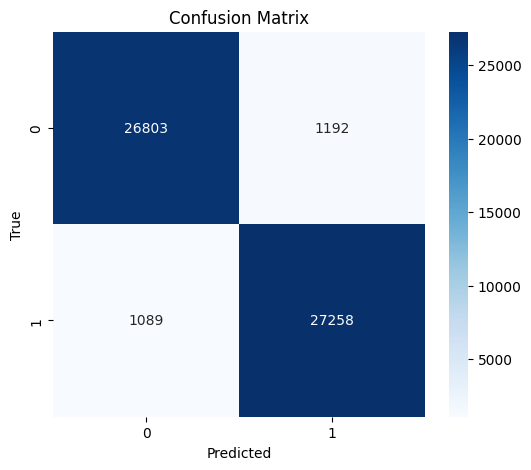

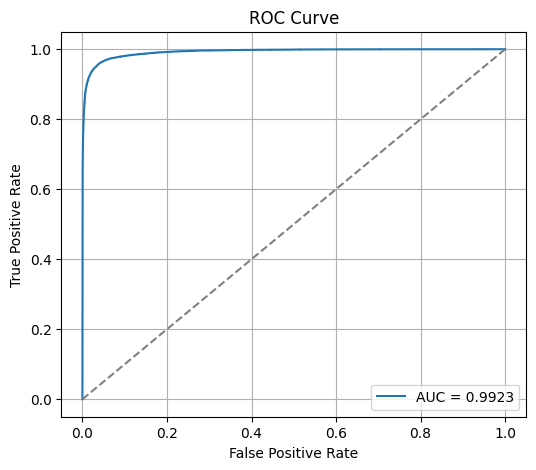

In [83]:
num_classes_CNN = df['source'].nunique()
cnn_model = CNNModel(
    vocab_size=vocab_size,
    embed_dim=128,
    num_classes=num_classes_CNN
).to(device)
trained_cnn, cnn_losses, cnn_accs = train_model(
    cnn_model,
    train_loader,
    test_loader,
    device,
    model_name='TextCNN',
    epochs=5
)
dl_history = {'cnn': {'loss': cnn_losses, 'accuracy': cnn_accs}}

In [84]:
dl_dir = Path('models/sentence/dl')
dl_dir.mkdir(parents=True, exist_ok=True)
torch.save(trained_cnn.state_dict(), dl_dir / 'sentence_cnn.pt')

BI-LSTM - Epoch 1/5, Loss: 0.1690, Accuracy: 0.9580
BI-LSTM - Epoch 2/5, Loss: 0.0848, Accuracy: 0.9632
BI-LSTM - Epoch 3/5, Loss: 0.0538, Accuracy: 0.9664
BI-LSTM - Epoch 4/5, Loss: 0.0329, Accuracy: 0.9652
BI-LSTM - Epoch 5/5, Loss: 0.0195, Accuracy: 0.9653

--- Model Evaluation ---
Evaluation - Accuracy:  0.9653
Evaluation - Precision: 0.9653
Evaluation - Recall:    0.9653
Evaluation - F1 Score:  0.9653
Evaluation - AUC-ROC:   0.9937


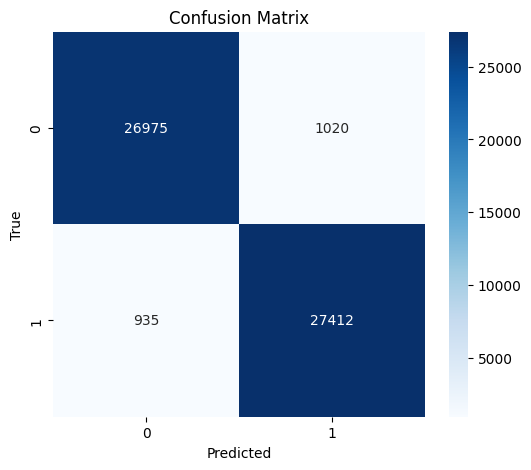

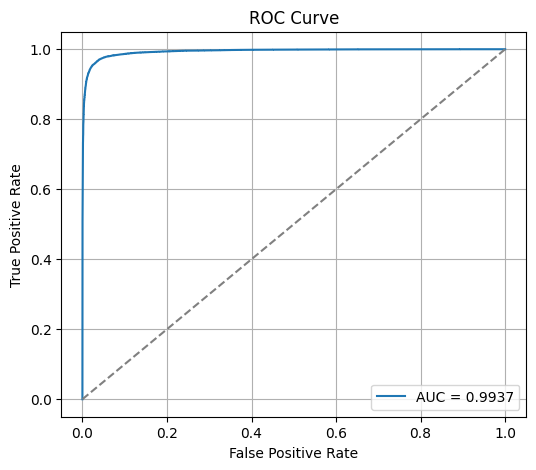

In [85]:
num_classes_BiLSTM = df['source'].nunique()
bilstm_model = BiLSTMModel(
    vocab_size=vocab_size,
    embed_dim=128,
    hidden_dim=64,
    output_dim=num_classes_BiLSTM
).to(device)
trained_bilstm, bilstm_losses, bilstm_accs = train_model(
    bilstm_model, train_loader, test_loader, device, model_name='BI-LSTM', epochs=5
)
dl_history['bilstm'] = {'loss': bilstm_losses, 'accuracy': bilstm_accs}

In [86]:
torch.save(trained_bilstm.state_dict(), dl_dir / 'sentence_bilstm.pt')

GRU - Epoch 1/5, Loss: 0.1815, Accuracy: 0.9598
GRU - Epoch 2/5, Loss: 0.0874, Accuracy: 0.9576
GRU - Epoch 3/5, Loss: 0.0568, Accuracy: 0.9644
GRU - Epoch 4/5, Loss: 0.0363, Accuracy: 0.9656
GRU - Epoch 5/5, Loss: 0.0243, Accuracy: 0.9649

--- Model Evaluation ---
Evaluation - Accuracy:  0.9649
Evaluation - Precision: 0.9649
Evaluation - Recall:    0.9649
Evaluation - F1 Score:  0.9649
Evaluation - AUC-ROC:   0.9934


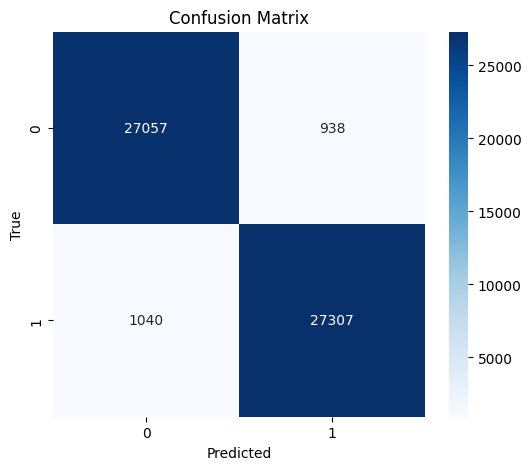

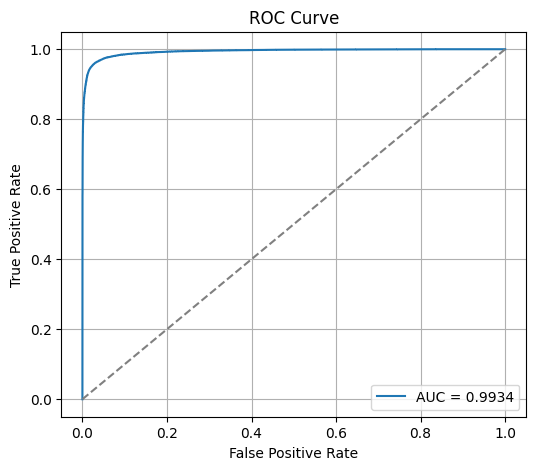

In [87]:
num_classes_GRU = df['source'].nunique()
gru_model = GRUModel(
    vocab_size=vocab_size,
    embed_dim=128,
    gru_hidden_dim=128,
    num_classes=num_classes_GRU
).to(device)
trained_gru, gru_losses, gru_accs = train_model(
    gru_model, train_loader, test_loader, device, model_name='GRU', epochs=5
)
dl_history['gru'] = {'loss': gru_losses, 'accuracy': gru_accs}

In [88]:
torch.save(trained_gru.state_dict(), dl_dir / 'sentence_gru.pt')

DNN - Epoch 1/5, Loss: 0.2296, Accuracy: 0.9467
DNN - Epoch 2/5, Loss: 0.1367, Accuracy: 0.9574
DNN - Epoch 3/5, Loss: 0.1118, Accuracy: 0.9601
DNN - Epoch 4/5, Loss: 0.0972, Accuracy: 0.9622
DNN - Epoch 5/5, Loss: 0.0875, Accuracy: 0.9618

--- Model Evaluation ---
Evaluation - Accuracy:  0.9618
Evaluation - Precision: 0.9618
Evaluation - Recall:    0.9618
Evaluation - F1 Score:  0.9618
Evaluation - AUC-ROC:   0.9928


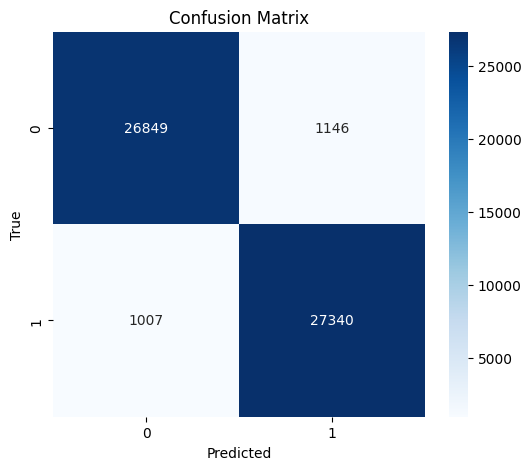

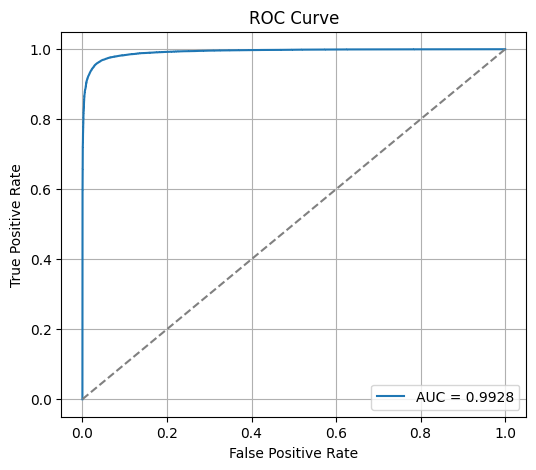

In [89]:
num_classes_DNN = df['source'].nunique()
dnn_model = DNNModel(
    vocab_size=vocab_size,
    embed_dim=128,
    num_classes=num_classes_DNN
).to(device)
trained_dnn, dnn_losses, dnn_accs = train_model(
    dnn_model, train_loader, test_loader, device, model_name='DNN', epochs=5
)
dl_history['dnn'] = {'loss': dnn_losses, 'accuracy': dnn_accs}

In [90]:
import gc

torch.save(trained_dnn.state_dict(), dl_dir / 'sentence_dnn.pt')
joblib.dump(tokenizer, dl_dir / 'sentence_tokenizer.pkl')

sentence_dl_config = {
    'max_vocab_size': max_vocab_size,
    'vocab_size': vocab_size,
    'max_len': max_len,
    'padding': 'post',
    'truncating': 'post',
    'label_mapping': label_mapping,
    'preprocessing': 'clean_text',
    'models': {
        'cnn': {'file': 'sentence_cnn.pt', 'embed_dim': 128, 'num_classes': int(num_classes_CNN)},
        'bilstm': {'file': 'sentence_bilstm.pt', 'embed_dim': 128, 'hidden_dim': 64, 'num_classes': int(num_classes_BiLSTM)},
        'gru': {'file': 'sentence_gru.pt', 'embed_dim': 128, 'gru_hidden_dim': 128, 'num_classes': int(num_classes_GRU)},
        'dnn': {'file': 'sentence_dnn.pt', 'embed_dim': 128, 'num_classes': int(num_classes_DNN)}
    }
}

with open(dl_dir / 'sentence_dl_config.json', 'w', encoding='utf-8') as file:
    json.dump(sentence_dl_config, file, indent=2)

pd.DataFrame([
    {'model': name, 'final_loss': values['loss'][-1], 'final_accuracy': values['accuracy'][-1]}
    for name, values in dl_history.items()
]).to_csv(metrics_dir / 'sentence_dl_metrics.csv', index=False)

with open(metrics_dir / 'sentence_dl_metrics.json', 'w', encoding='utf-8') as file:
    json.dump(dl_history, file, indent=2)

for name in [
    'trained_cnn', 'trained_bilstm', 'trained_gru', 'trained_dnn',
    'cnn_model', 'bilstm_model', 'gru_model', 'dnn_model',
    'train_loader', 'test_loader', 'train_dataset', 'test_dataset',
    'X_train_tensor', 'X_test_tensor', 'y_train_tensor', 'y_test_tensor',
    'cnn_losses', 'cnn_accs', 'bilstm_losses', 'bilstm_accs', 'gru_losses', 'gru_accs', 'dnn_losses', 'dnn_accs'
]:
    if name in globals():
        del globals()[name]

if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()
print('Saved DL artifacts and released DL training objects from memory.')


Saved DL artifacts and released DL training objects from memory.


In [91]:
df.head()

,cleaned_text,source
0,"t-mobile, sprint or at t we'll check with the ...",1
1,"based on a variety of factors, some of the hig...",1
2,depending on if you count uavs it s the army iirc,0
3,possible stock ticker symbols for psec:psec: t...,1
4,the kyoto protocol was agreed upon between nat...,1


In [92]:
import gc

MODEL_DATA_PATH = Path('data/sentence_model.pkl')
required_columns = {'cleaned_text', 'source'}

if 'df' in globals() and required_columns.issubset(df.columns):
    df = df[['cleaned_text', 'source']].copy()
    df['source'] = df['source'].astype('int8')
    print('Using existing in-memory compact df for transformers; no file was read.')
elif MODEL_DATA_PATH.exists():
    df = pd.read_pickle(MODEL_DATA_PATH)
    print('Loaded compact modeling data from:', MODEL_DATA_PATH)
else:
    raise FileNotFoundError(
        f'{MODEL_DATA_PATH} does not exist. Run the preprocessing/save cell first. '
        'The old data/sentence.pkl can be too large to load safely.'
    )

gc.collect()


Using existing in-memory compact df for transformers; no file was read.


0

In [93]:
from transformers import (
    RobertaTokenizer,
    ElectraTokenizer
)

from TransformersTraining import build_roberta, build_electra, split_dataframe, train_Transformers

transformer_dir = Path('models/sentence/transformers')
transformer_dir.mkdir(parents=True, exist_ok=True)
train_df, val_df, test_df = split_dataframe(df)

Epoch 1:  12%|█▏        | 999/8217 [07:19<53:01,  2.27it/s, loss=0.134] 


Saved checkpoint at iter 1000: models\sentence\transformers\roberta\ckpt_iter1000.pt


Epoch 1:  12%|█▏        | 1000/8217 [07:42<14:28:13,  7.22s/it, loss=0.134, avg_train_loss=0.309, val_loss=0.257]


Saved improved checkpoint: models\sentence\transformers\roberta\best_iter1000_val_0.2566.pt


Epoch 1:  24%|██▍       | 1999/8217 [15:00<45:35,  2.27it/s, loss=0.0423]                                        

...


Saved improved checkpoint: models\sentence\transformers\roberta\best_iter23000_val_0.0300.pt


Epoch 3:  92%|█████████▏| 7565/8217 [59:13<05:05,  2.14it/s, loss=0.0435]                                       


Saved checkpoint at iter 24000: models\sentence\transformers\roberta\ckpt_iter24000.pt


Epoch 3: 100%|██████████| 8217/8217 [1:04:27<00:00,  2.12it/s, loss=0.425]                                       


Epoch 3 validation loss: 0.1054


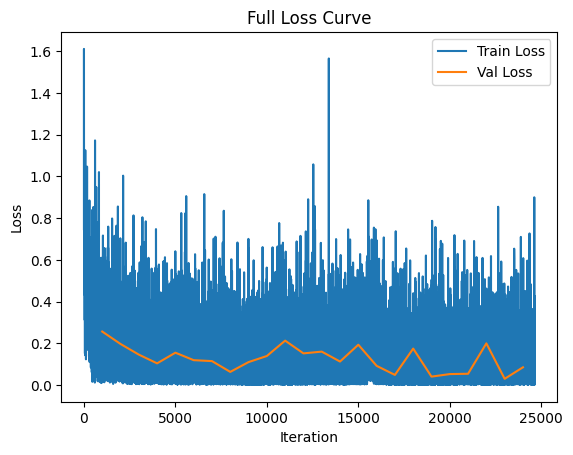

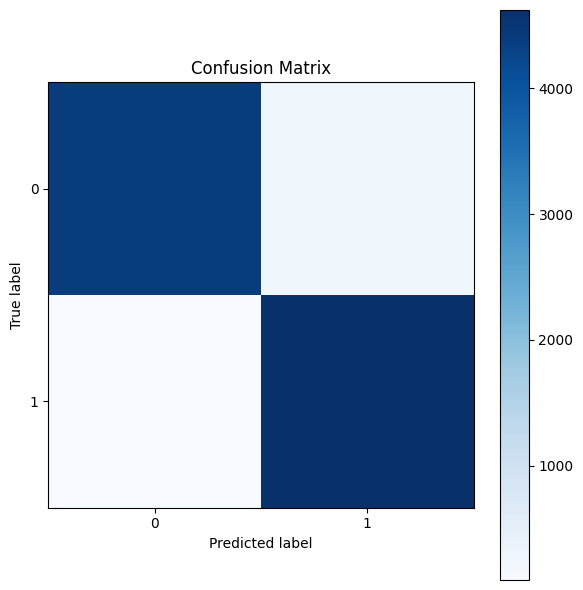

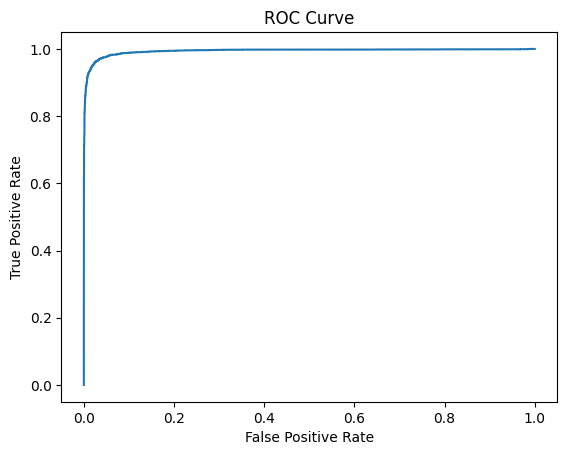

Released RoBERTa objects from memory.


In [94]:
roberta = build_roberta()
roberta_tokenizer = RobertaTokenizer.from_pretrained(
    'roberta-base',
    cache_dir=str(TRANSFORMERS_CACHE_DIR)
)
train_Transformers(
    roberta,
    roberta_tokenizer,
    train_df,
    val_df,
    lr=2e-5,
    weight_decay=0.01,
    epochs=3,
    loss_check=1000,
    checkpoint_dir=transformer_dir / 'roberta'
)

del roberta, roberta_tokenizer
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()
print('Released RoBERTa objects from memory.')


Epoch 1:  12%|█▏        | 999/8217 [08:01<54:07,  2.22it/s, loss=0.142]   


Saved checkpoint at iter 1000: models\sentence\transformers\electra\ckpt_iter1000.pt


Epoch 1:  12%|█▏        | 1000/8217 [08:24<14:50:34,  7.40s/it, loss=0.142, avg_train_loss=0.312, val_loss=0.182]


Saved improved checkpoint: models\sentence\transformers\electra\best_iter1000_val_0.1822.pt


Epoch 1:  24%|██▍       | 1999/8217 [16:19<48:04,  2.16it/s, loss=0.261]                                         

...


Saved checkpoint at iter 23000: models\sentence\transformers\electra\ckpt_iter23000.pt


Epoch 3:  92%|█████████▏| 7565/8217 [58:23<04:53,  2.22it/s, loss=0.246]                                       


Saved checkpoint at iter 24000: models\sentence\transformers\electra\ckpt_iter24000.pt


Epoch 3: 100%|██████████| 8217/8217 [1:03:24<00:00,  2.16it/s, loss=0.00229]                                    


Epoch 3 validation loss: 0.1046


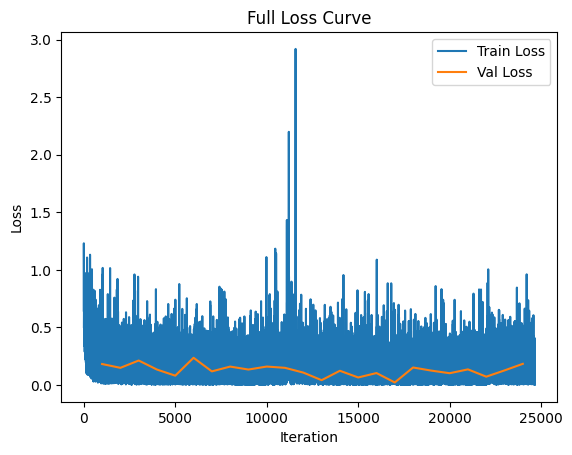

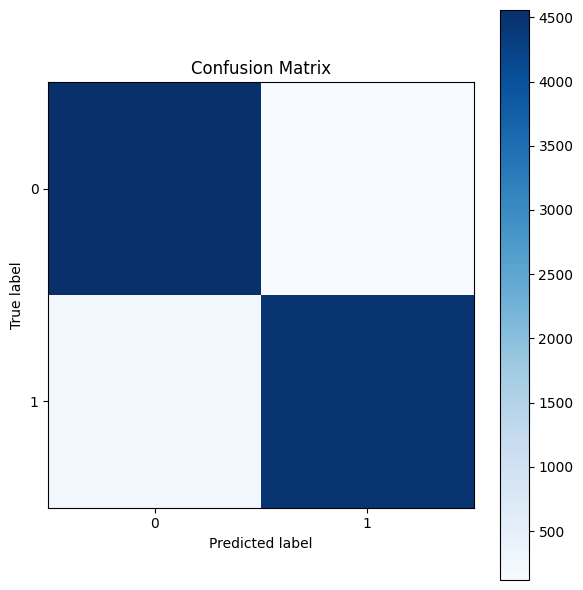

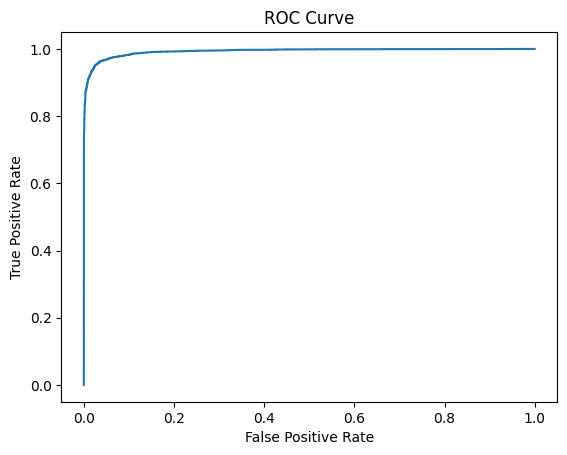

Released ELECTRA and transformer split objects from memory.


In [95]:
electra = build_electra()
electra_tokenizer = ElectraTokenizer.from_pretrained(
    'google/electra-base-discriminator',
    cache_dir=str(TRANSFORMERS_CACHE_DIR)
)
train_Transformers(
    electra,
    electra_tokenizer,
    train_df,
    val_df,
    lr=2e-5,
    weight_decay=0.01,
    epochs=3,
    loss_check=1000,
    checkpoint_dir=transformer_dir / 'electra'
)

del electra, electra_tokenizer, train_df, val_df, test_df
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()
print('Released ELECTRA and transformer split objects from memory.')


In [96]:
legacy_path = Path('models/sentences_passive_aggressive_pipeline.pkl')
if legacy_path.exists():
    print('Legacy pipeline already saved at:', legacy_path)
else:
    model_path = Path('models/sentence/ml/sentence_passive_aggressive.pkl')
    if not model_path.exists():
        raise FileNotFoundError('Passive Aggressive model was not found. Run the ML training/save cells first.')
    legacy_path.parent.mkdir(exist_ok=True)
    pa_pipeline = joblib.load(model_path)
    joblib.dump(pa_pipeline, legacy_path)
    del pa_pipeline
    print('Pipeline saved to:', legacy_path)


Legacy pipeline already saved at: models\sentences_passive_aggressive_pipeline.pkl
